In [1]:
import pandas as pd

In [5]:
df = pd.read_excel(r"C:\Users\sheji\Downloads\big_tech_ai_spending2.xlsx", sheet_name="Data", nrows=40)
df.columns = ["company", "fiscal_year", "fy_end", "year", "revenue",
              "op_income", "net_income", "rnd", "capex", "source",
              "rev_growth", "op_margin", "net_margin", "rnd_pct",
              "capex_pct", "rnd_capex_pct"]

print(df.shape)
print(df.dtypes)
print(df.isna().sum())
print(df.groupby("company").size())

(40, 16)
company                  object
fiscal_year              object
fy_end           datetime64[ns]
year                      int64
revenue                   int64
op_income                 int64
net_income                int64
rnd                       int64
capex                     int64
source                   object
rev_growth              float64
op_margin               float64
net_margin              float64
rnd_pct                 float64
capex_pct               float64
rnd_capex_pct           float64
dtype: object
company          0
fiscal_year      0
fy_end           0
year             0
revenue          0
op_income        0
net_income       0
rnd              0
capex            0
source           0
rev_growth       5
op_margin        0
net_margin       0
rnd_pct          0
capex_pct        0
rnd_capex_pct    0
dtype: int64
company
Amazon       8
Google       8
Meta         8
Microsoft    8
NVIDIA       8
dtype: int64


In [6]:

df["period"] = df["year"].apply(lambda y: "Pre-AI (2018-22)" if y <= 2022 else "AI boom (2023-25)")
df["capex_to_opinc"] = df["capex"] / df["op_income"]
buyers = df[df["company"] != "NVIDIA"].groupby("year")["capex"].sum()
nvda_rev = df[df["company"] == "NVIDIA"].set_index("year")["revenue"]

supply = pd.DataFrame({"buyers_capex": buyers, "nvda_revenue": nvda_rev})
supply["buyers_capex_growth"] = supply["buyers_capex"].pct_change()
supply["nvda_rev_growth"] = supply["nvda_revenue"].pct_change()

print(df[df["year"] == 2025][["company", "capex", "op_income", "capex_to_opinc"]])
print(supply)

      company   capex  op_income  capex_to_opinc
7      Amazon  131819      79975        1.648253
15     Google   91447     129039        0.708677
23       Meta   69691      83276        0.836868
31  Microsoft  115948     155237        0.746910
39     NVIDIA    6042     130387        0.046339
      buyers_capex  nvda_revenue  buyers_capex_growth  nvda_rev_growth
year                                                                  
2018         66406         11716                  NaN              NaN
2019         70952         10918             0.068458        -0.068112
2020         98206         16675             0.384119         0.527294
2021        128269         26914             0.306122         0.614033
2022        154668         26974             0.205810         0.002229
2023        156502         60922             0.011858         1.258545
2024        237341        130497             0.516537         1.142034
2025        408905        215938             0.722859         0.654

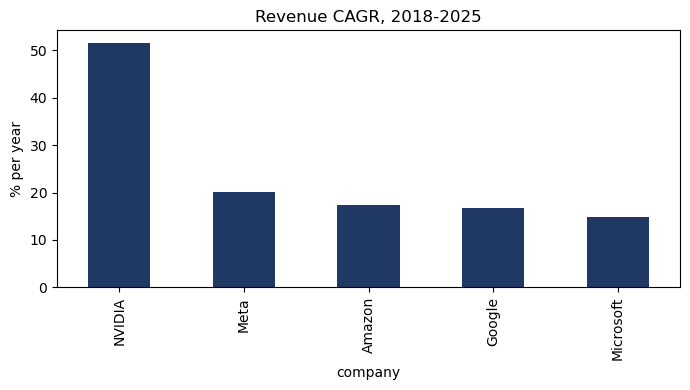

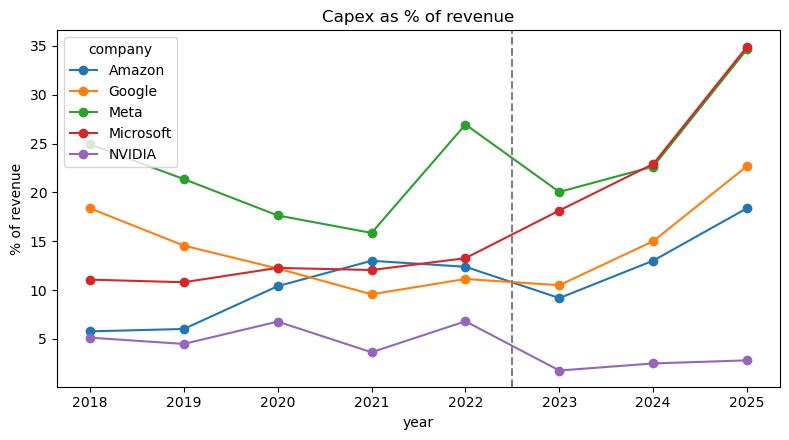

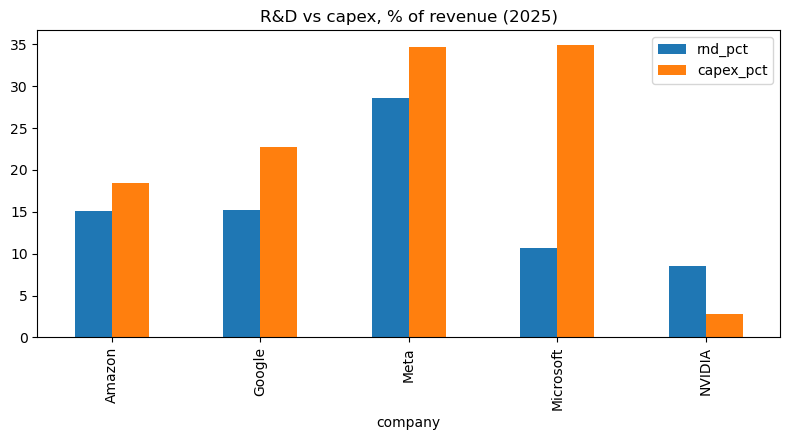

In [8]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

first = df[df["year"] == 2018].set_index("company")["revenue"]
last = df[df["year"] == 2025].set_index("company")["revenue"]
cagr = ((last / first) ** (1 / 7) - 1).sort_values(ascending=False) * 100

ax = cagr.plot(kind="bar", figsize=(7, 4), color="#1F3864")
ax.set_title("Revenue CAGR, 2018-2025")
ax.set_ylabel("% per year")
plt.tight_layout()
plt.show()

pivot = df.pivot(index="year", columns="company", values="capex_pct") * 100
ax = pivot.plot(figsize=(8, 4.5), marker="o")
ax.set_title("Capex as % of revenue")
ax.set_ylabel("% of revenue")
ax.axvline(2022.5, color="grey", linestyle="--")   # start of the AI boom period
plt.tight_layout()
plt.show()

d25 = df[df["year"] == 2025].set_index("company")[["rnd_pct", "capex_pct"]] * 100
ax = d25.plot(kind="bar", figsize=(8, 4.5))
ax.set_title("R&D vs capex, % of revenue (2025)")
plt.tight_layout()
plt.show()

# After AI Boom

In [9]:
import pandas as pd
pd.set_option("display.max_columns", None)   # show every column

cols = ["rev_growth", "op_margin", "rnd_pct", "capex_pct"]
g = df.groupby(["company", "period"])

summary = g[cols].mean() * 100                      
summary["capex_to_opinc"] = g["capex_to_opinc"].mean()
print(summary.round(1))

wide = summary.unstack("period")
change = (wide.xs("AI boom (2023-25)", axis=1, level="period")
          - wide.xs("Pre-AI (2018-22)", axis=1, level="period"))
print(change.round(1))

                             rev_growth  op_margin  rnd_pct  capex_pct  \
company   period                                                         
Amazon    AI boom (2023-25)        11.7        9.4     14.6       13.5   
          Pre-AI (2018-22)         22.3        4.8     12.5        9.5   
Google    AI boom (2023-25)        12.5       30.5     14.7       16.1   
          Pre-AI (2018-22)         20.5       24.2     14.6       13.2   
Meta      AI boom (2023-25)        19.9       39.4     27.9       25.8   
          Pre-AI (2018-22)         21.1       36.2     22.1       21.3   
Microsoft AI boom (2023-25)        16.1       45.7     11.4       25.3   
          Pre-AI (2018-22)         14.0       39.3     12.9       11.9   
NVIDIA    AI boom (2023-25)       101.8       59.0     10.9        2.3   
          Pre-AI (2018-22)         26.9       27.7     23.3        5.4   

                             capex_to_opinc  
company   period                             
Amazon    AI boom (

      buyers_capex  nvda_revenue  nvda_pct_of_capex  buyers_capex_growth  \
year                                                                       
2018         66406         11716               17.6                  NaN   
2019         70952         10918               15.4                  6.8   
2020         98206         16675               17.0                 38.4   
2021        128269         26914               21.0                 30.6   
2022        154668         26974               17.4                 20.6   
2023        156502         60922               38.9                  1.2   
2024        237341        130497               55.0                 51.7   
2025        408905        215938               52.8                 72.3   

      nvda_rev_growth  
year                   
2018              NaN  
2019             -6.8  
2020             52.7  
2021             61.4  
2022              0.2  
2023            125.9  
2024            114.2  
2025             65.5  

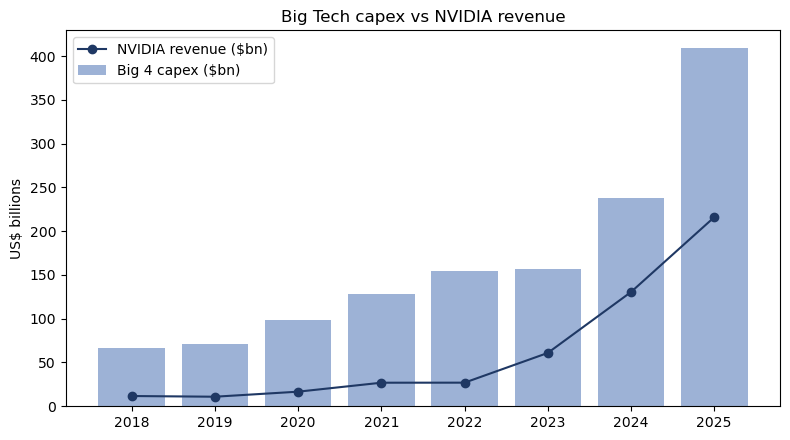

In [10]:
import matplotlib.pyplot as plt

buyers = df[df["company"] != "NVIDIA"].groupby("year")["capex"].sum()
nvda_rev = df[df["company"] == "NVIDIA"].set_index("year")["revenue"]

supply = pd.DataFrame({"buyers_capex": buyers, "nvda_revenue": nvda_rev})
supply["nvda_pct_of_capex"] = supply["nvda_revenue"] / supply["buyers_capex"] * 100
supply["buyers_capex_growth"] = supply["buyers_capex"].pct_change() * 100
supply["nvda_rev_growth"] = supply["nvda_revenue"].pct_change() * 100
print(supply.round(1))

print("level corr:", round(supply["buyers_capex"].corr(supply["nvda_revenue"]), 2))
print("growth corr:", round(supply["buyers_capex_growth"].corr(supply["nvda_rev_growth"]), 2))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(supply.index, supply["buyers_capex"] / 1000, color="#9DB2D6", label="Big 4 capex ($bn)")
ax.plot(supply.index, supply["nvda_revenue"] / 1000, color="#1F3864", marker="o", label="NVIDIA revenue ($bn)")
ax.set_title("Big Tech capex vs NVIDIA revenue")
ax.set_ylabel("US$ billions")
ax.legend()
plt.tight_layout()
plt.show()

df.to_csv("big_tech_clean.csv", index=False)

In [11]:
df[["company", "fiscal_year", "fy_end", "year", "revenue",
    "op_income", "net_income", "rnd", "capex"]].to_csv("big_tech_sql.csv", index=False)

In [12]:
import os
print(os.path.abspath("big_tech_sql.csv"))

C:\Users\sheji\big_tech_sql.csv
